In [43]:
# import python libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import machine learning tools for preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib 

In [44]:
# Load the dataset using cp1252 encoding to handle special characters
df = pd.read_csv('Superstore.csv', encoding="cp1252")

In [45]:
# Feature Engineering: Create interaction terms to capture deeper financial relationships
df['Profit_Margin'] = np.where(df['Sales'] == 0, 0, df['Profit'] / df['Sales'])
df['Sales_x_Discount'] = df['Sales'] * df['Discount']
df['Quantity_x_Discount'] = df['Quantity'] * df['Discount']

In [46]:
# Data Cleaning: Remove high-cardinality and non-predictive identifier columns
df.drop(columns=['Order ID', 'Customer ID', 'Product ID', 'Order Date', 'Ship Date', 
                 'Customer Name', 'Postal Code', 'Product Name', 'Country', 'City'], 
        axis=1, inplace=True)

In [47]:
# Target Transformation: Convert Profit into a binary classification target (1 for Profit, 0 for Loss)
df['Profitable'] = df['Profit'].apply(lambda x: 1 if x > 0 else 0)

In [48]:
# Feature-Target Split: Separate independent variables (X) from the dependent target (y)
X = df.drop(['Profit', 'Profitable'], axis=1)
y = df['Profitable']

In [49]:
# Identify column types dynamically for automated preprocessing steps
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

In [50]:
# Train-Test Split: Reserve 20% of the data for final model evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
# Preprocessing Pipeline: Scaling for numerical data and One-Hot Encoding for categories
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ], 
    remainder='drop'
)

In [52]:
# Initialize SMOTE to handle class imbalance (addressing the skew in profitable vs non-profitable orders)
smote = SMOTE(random_state=42)

In [53]:

# Define baseline models: Logistic Regression (with balanced weights) and Random Forest
log_reg_base = LogisticRegression(max_iter=1000, class_weight='balanced')
rf_base = RandomForestClassifier(random_state=42)

In [54]:
# Construct various model pipelines to automate preprocessing and sampling during training
pipeline_lr_base = Pipeline(steps=[('preprocessor', preprocessor), ('model', log_reg_base)])
pipeline_lr_smote = Pipeline(steps=[('preprocessor', preprocessor), ('sampler', smote), ('model', log_reg_base)])
pipeline_rf_base = Pipeline(steps=[('preprocessor', preprocessor), ('model', rf_base)])
pipeline_rf_smote = Pipeline(steps=[('preprocessor', preprocessor), ('sampler', smote), ('model', rf_base)])

In [55]:
# Fit all model variations to prepare them for the model registry
pipeline_lr_base.fit(X_train, y_train)
pipeline_lr_smote.fit(X_train, y_train)
pipeline_rf_base.fit(X_train, y_train)
pipeline_rf_smote.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Row ID', 'Sales',
                                                   'Quantity', 'Discount',
                                                   'Profit_Margin',
                                                   'Sales_x_Discount',
                                                   'Quantity_x_Discount']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Ship Mode', 'Segment',
                                                   'State', 'Region',
                                                   'Category',
                                                   'Sub-Category'])])),
                ('sampler', SMOTE(random_state=42)),
                ('model', RandomForestClassifier(random_state=42))])

In [56]:
# Generate predictions using the best performing model (Random Forest + SMOTE)
y_pred = pipeline_rf_smote.predict(X_test)

In [57]:
# Output evaluation metrics for the final model selection
print('Accuracy Score:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       387
           1       1.00      1.00      1.00      1612

    accuracy                           1.00      1999
   macro avg       1.00      1.00      1.00      1999
weighted avg       1.00      1.00      1.00      1999


Confusion Matrix:
 [[ 387    0]
 [   0 1612]]


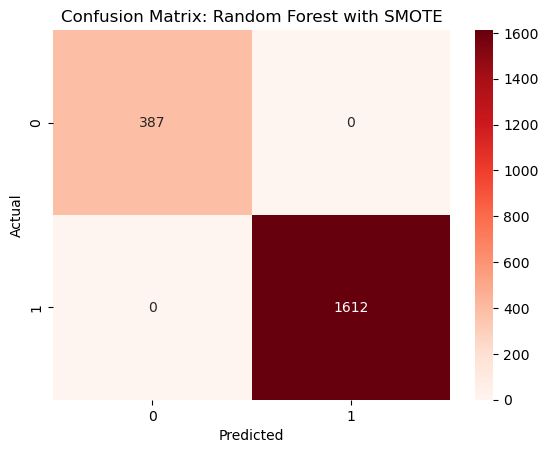

In [58]:
# Visualise the Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest with SMOTE')
plt.show()

In [59]:
# Model Registry: Consolidate all trained pipelines into a single dictionary
superstore_models = {
    'log_reg_base': pipeline_lr_base,      
    'log_reg_smote': pipeline_lr_smote,            
    'rf_base': pipeline_rf_base,                 
    'rf_smote': pipeline_rf_smote            
}

# Joblib Export: Save all models, preprocessors, and samplers into one file for deployment
joblib.dump(superstore_models, 'superstore_all_models.joblib')

print("All Superstore project models successfully saved to 'superstore_all_models.joblib'")

All Superstore project models successfully saved to 'superstore_all_models.joblib'
